<a href="https://colab.research.google.com/github/santhroshan/3D-Color-segementation-to-detect-Diabetic-Retinopathy/blob/main/Vessel_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload the Excel file containing disease information:


Saving Text labels.xlsx to Text labels (1).xlsx
Please upload the OCTA image (or type 'Stop' to exit):


Saving 10005.bmp to 10005.bmp


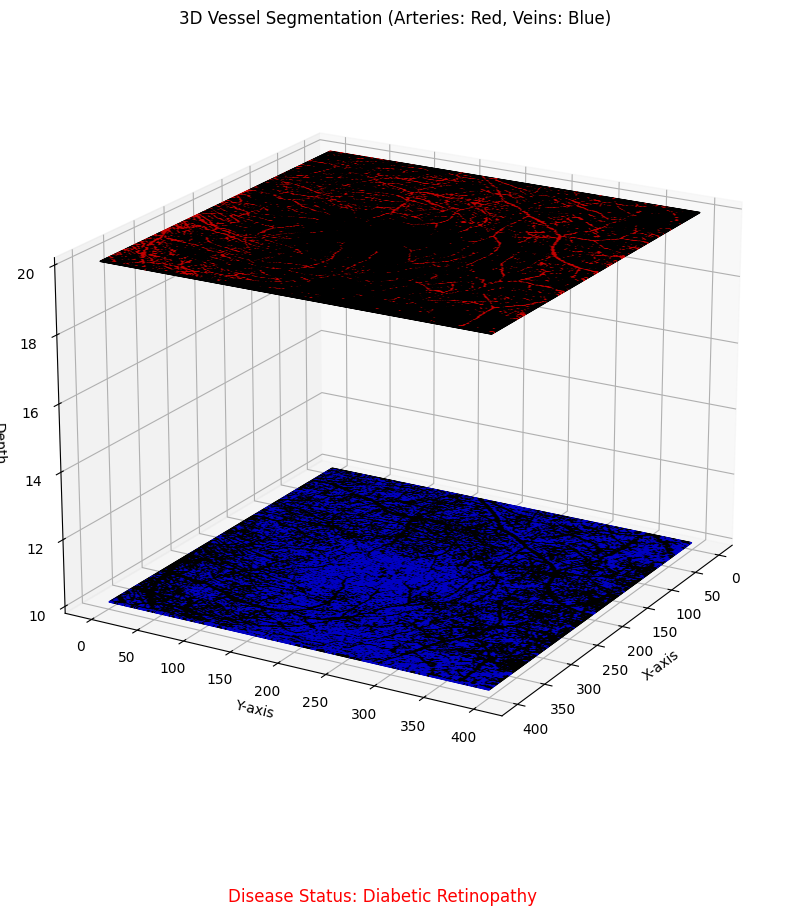

Please upload the OCTA image (or type 'Stop' to exit):


Saving 10001.bmp to 10001 (1).bmp


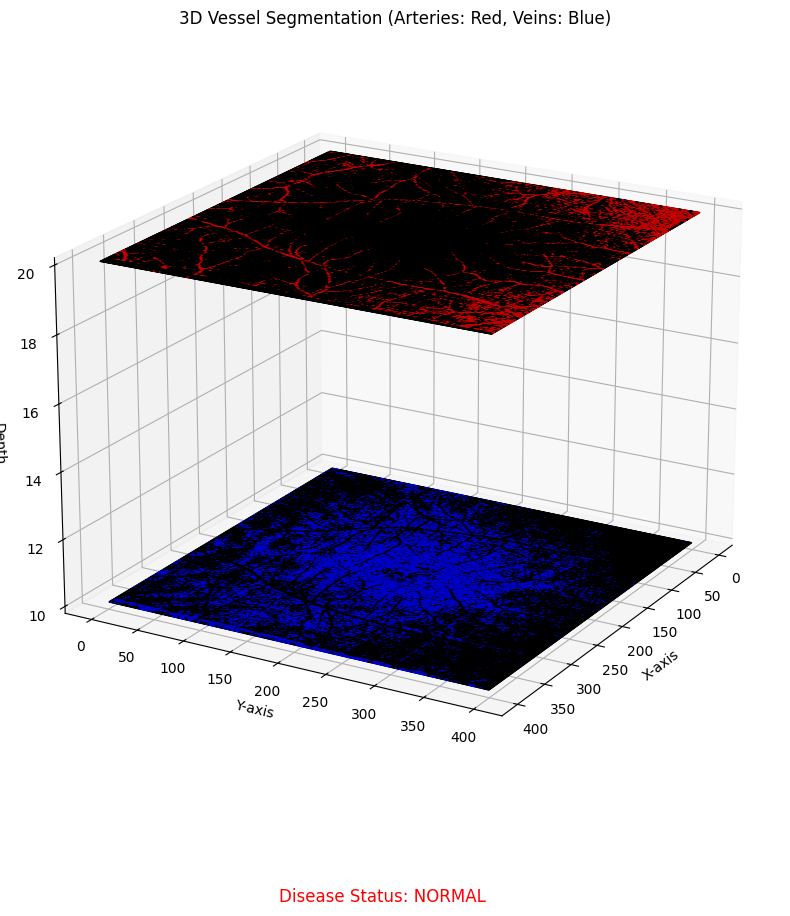

Please upload the OCTA image (or type 'Stop' to exit):


TypeError: 'NoneType' object is not subscriptable

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from google.colab import files
from PIL import Image
import cv2
import pandas as pd
import re

# Step 1: Upload the Excel file
print("Please upload the Excel file containing disease information:")
uploaded = files.upload()

# Get the filename
excel_filename = list(uploaded.keys())[0]
df = pd.read_excel(excel_filename)

# Step 2: Loop for multiple input images until stopped
while True:
    print("Please upload the OCTA image (or type 'Stop' to exit):")
    uploaded = files.upload()

    if 'Stop' in uploaded:
        break

    # Get the filename
    filename = list(uploaded.keys())[0]

    # Step 3: Load the image and convert to grayscale
    image = Image.open(filename).convert('L')
    image = np.array(image)

    # Step 4: Apply vessel segmentation using thresholding
    normalized = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
    arteries = cv2.inRange(normalized, 180, 255)  # Brighter regions for arteries
    veins = cv2.inRange(normalized, 30, 100)      # Darker regions for veins

    # Step 5: Create 3D model
    x, y = np.meshgrid(np.arange(image.shape[1]), np.arange(image.shape[0]))
    z_arteries = np.full_like(x, 20) # Set depth for arteries
    z_veins = np.full_like(x, 10)    # Set depth for veins

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Plot arteries (in red)
    ax.plot_surface(x, y, z_arteries, facecolors=np.dstack((arteries/255, np.zeros_like(arteries), np.zeros_like(arteries))), rstride=1, cstride=1, alpha=0.8)

    # Plot veins (in blue)
    ax.plot_surface(x, y, z_veins, facecolors=np.dstack((np.zeros_like(veins), np.zeros_like(veins), veins/255)), rstride=1, cstride=1, alpha=0.8)

    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')
    ax.set_zlabel('Depth')

    # Enable 360-degree rotation
    ax.view_init(elev=20, azim=30)
    ax.set_title('3D Vessel Segmentation (Arteries: Red, Veins: Blue)')

    # Step 6: Find the disease status by comparing the numeric part of the filename with the "ID" column in Excel
    # Extract numeric part of filename
    image_id = re.findall(r'\d+', filename)[0] if re.findall(r'\d+', filename) else None

    if image_id is not None:
        # Convert IDs in Excel to string and remove leading/trailing spaces
        df['ID'] = df['ID'].astype(str).str.strip()
        matched_row = df.loc[df['ID'].str.contains(image_id, case=False, na=False)]
        disease_status = matched_row['Disease'].values[0] if not matched_row.empty else "No Data"
    else:
        disease_status = "No Data"

    # Display disease status below the output
    plt.figtext(0.5, 0.01, f'Disease Status: {disease_status}', ha="center", fontsize=12, color="red")

    plt.show()

    # Allow rotation after display
    plt.pause(0.1)




